# Importing libraries and reading the data

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy import stats
import warnings
warnings.simplefilter(action='ignore')

In [2]:
data = pd.read_csv("insdata100k.csv")
if "person_id" in data.columns:
    data.drop(columns=["person_id"], inplace=True)

In [3]:
data.head()

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,...,0,1,0,1,0,2,0,1,0,0
1,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,...,0,1,1,0,0,1,0,1,1,0
2,68,Male,North,Rural,40700.0,HS,Married,Retired,5,3,...,0,0,1,1,0,2,1,0,1,0
3,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,3,...,0,0,0,1,0,0,1,0,0,0
4,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,...,0,1,0,2,0,1,1,0,1,0


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 53 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   sex                          100000 non-null  str    
 2   region                       100000 non-null  str    
 3   urban_rural                  100000 non-null  str    
 4   income                       100000 non-null  float64
 5   education                    100000 non-null  str    
 6   marital_status               100000 non-null  str    
 7   employment_status            100000 non-null  str    
 8   household_size               100000 non-null  int64  
 9   dependents                   100000 non-null  int64  
 10  bmi                          100000 non-null  float64
 11  smoker                       100000 non-null  str    
 12  alcohol_freq                 69917 non-null   str    
 13  visits_last

In [5]:
data.describe()

,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,117.808970,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,15.369187,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,61.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,107.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,117.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,128.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,183.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


## Removing Outliers from charges column

In [6]:
data['annual_medical_cost'].median()

np.float64(2082.575)

In [7]:
data['annual_medical_cost'].mean()

np.float64(3009.4519069999997)

In [8]:
data=data[np.abs(stats.zscore(data['annual_medical_cost'])) < 3]

In [9]:
data.describe()

,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,98124.000000,9.812400e+04,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,...,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000,98124.000000
mean,47.415128,4.987491e+04,2.430364,0.898292,26.984623,1.906679,0.088877,0.349007,1.228772,117.690045,...,0.014207,0.106253,0.127400,0.505992,0.156557,0.506054,0.507582,0.506502,0.361033,0.165872
std,15.967755,4.680422e+04,1.074857,0.950702,4.996617,1.715525,0.296323,1.315841,1.204456,15.325002,...,0.118342,0.308163,0.333422,0.746536,0.458026,0.743101,0.750266,0.746995,0.480303,0.371967
min,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,61.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.000000,0.000000,0.000000,0.000000,107.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,47.000000,3.620000e+04,2.000000,1.000000,27.000000,2.000000,0.000000,0.000000,1.000000,117.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.000000,0.000000,0.000000,2.000000,128.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.000000,3.000000,21.000000,11.000000,183.000000,...,1.000000,1.000000,1.000000,7.000000,5.000000,7.000000,7.000000,7.000000,1.000000,1.000000


# Visualizing the data columns

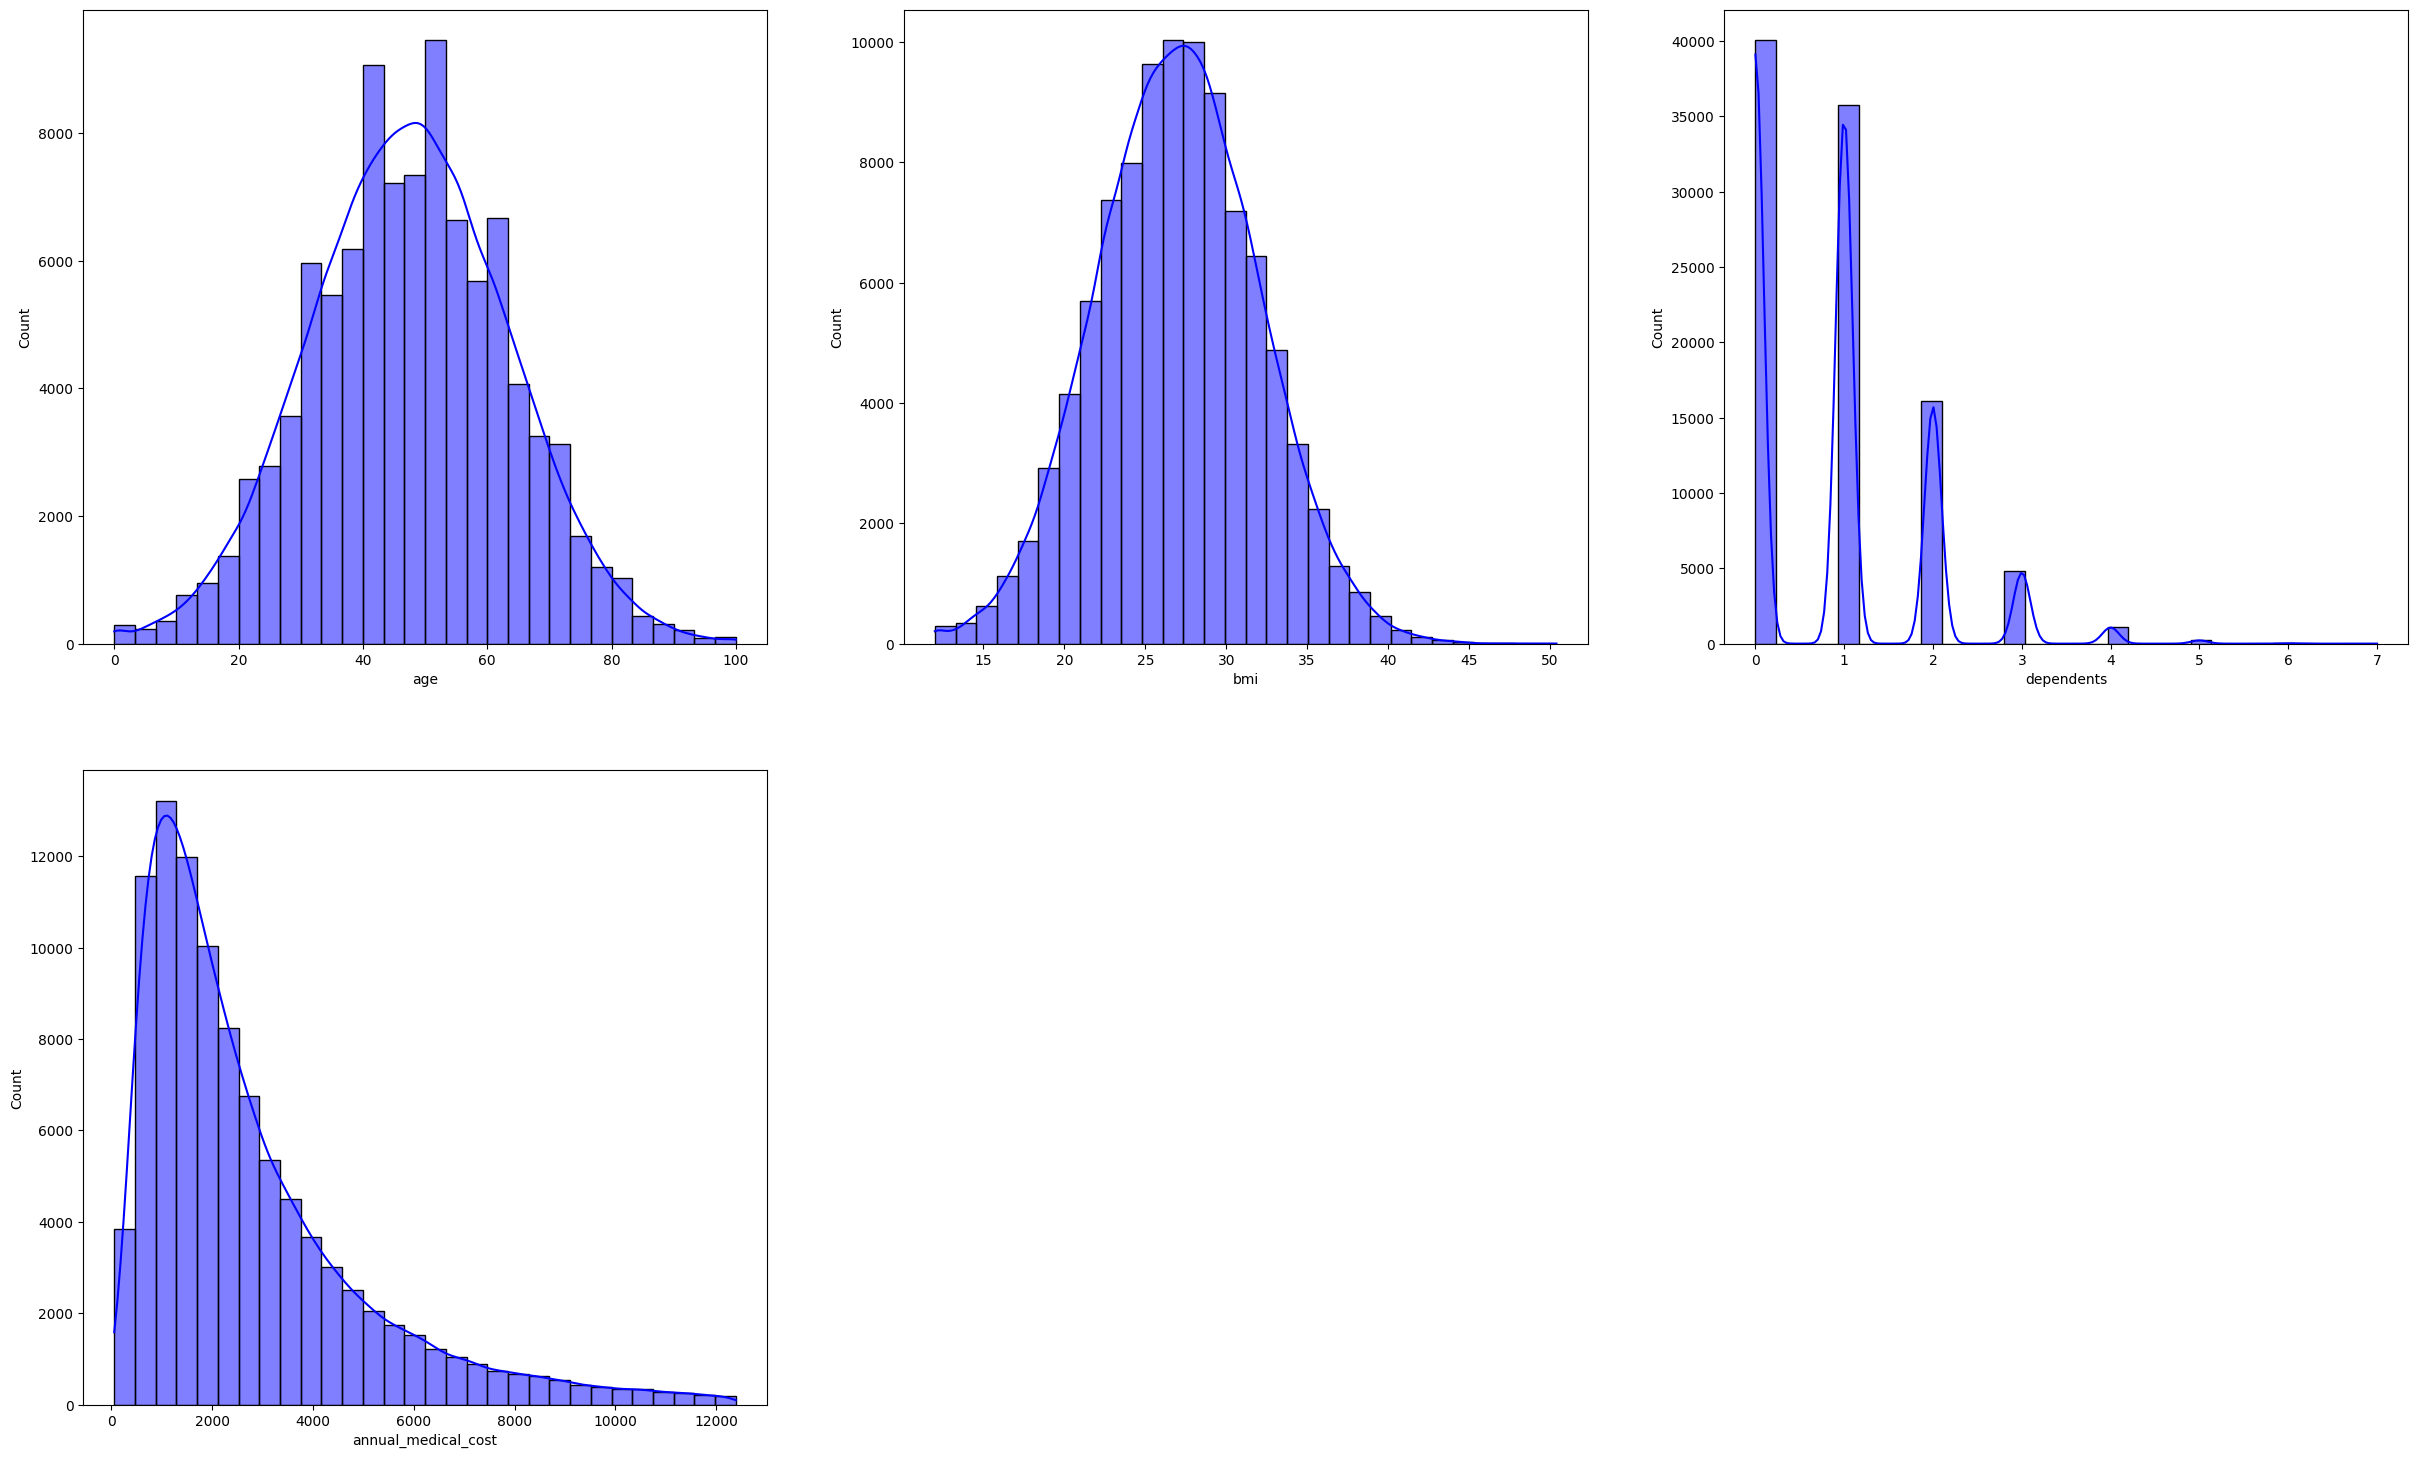

In [10]:
plt.figure(figsize=(30,28))
for i, col in enumerate( ['age','bmi','dependents','annual_medical_cost']):
    plt.subplot(3, 3, i+1)
    sns.histplot(data = data,
            x = col,
            kde = True,
            bins = 30,
            color = 'blue')

plt.show()

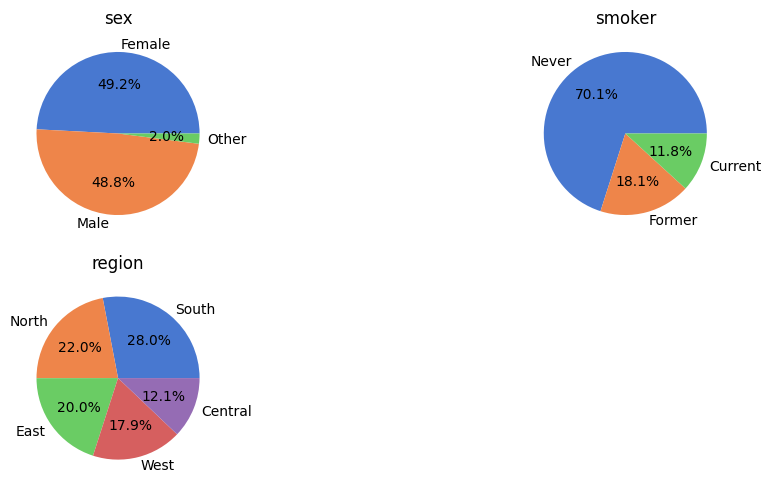

In [11]:
plt.figure(figsize=(12,9))
for i,col in enumerate(['sex','smoker','region']):
    plt.subplot(3,2,i+1)
    x=data[col].value_counts().reset_index()
    plt.title(col)
    plt.pie(x=x['count'],labels=x[col],autopct="%0.1f%%",colors=sns.color_palette('muted'))

# Analyzing the data

In [12]:
data_corr= data.copy()
label_encoder = LabelEncoder()
for col in data_corr.select_dtypes(include='object').columns:
    data_corr[col] = label_encoder.fit_transform(data_corr[col])
data_corr.head()

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,52,0,2,1,22700.0,1,1,1,3,1,...,0,1,0,1,0,2,0,1,0,0
1,79,0,2,2,12800.0,4,1,0,3,1,...,0,1,1,0,0,1,0,1,1,0
2,68,1,2,0,40700.0,2,1,1,5,3,...,0,0,1,1,0,2,1,0,1,0
3,15,1,2,1,15600.0,5,1,2,5,3,...,0,0,0,1,0,0,1,0,0,0
4,53,1,0,1,89600.0,1,1,2,2,0,...,0,1,0,2,0,1,1,0,1,0


In [13]:
data_corr = data_corr.corr()

<Axes: >

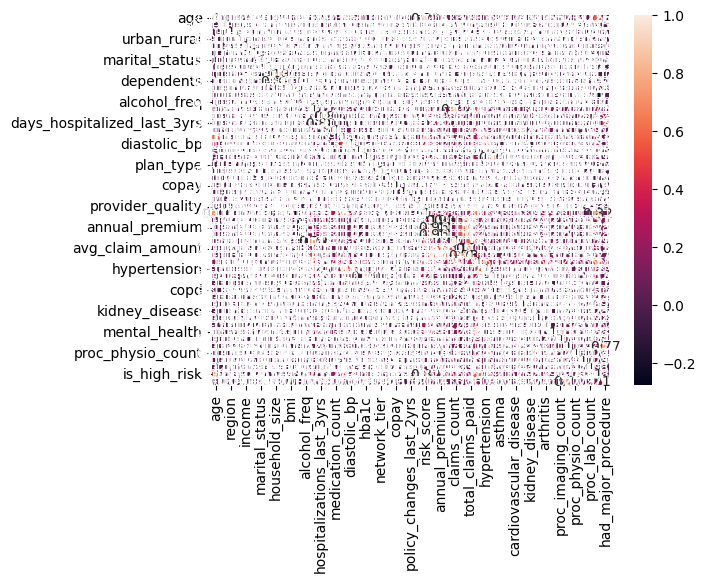

In [14]:
sns.heatmap(data=data_corr,annot=True)

In [15]:
# sns.pairplot(data=data)
# plt.show()

In [16]:
# sns.scatterplot(data=data,x=data.annual_medical_cost,y=data.smoker,hue=data.age)
# plt.show()

In [17]:
# data.groupby('sex')['annual_medical_cost'].median()

In [18]:
# sns.barplot(data=data,x=data.sex,y=data.annual_medical_cost,estimator=np.mean)
# plt.show()

In [19]:
# sns.barplot(data=data,x=data.region,y=data.annual_medical_cost,estimator=np.mean)
# plt.show()

# Splitting the data and getting dummies

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.model_selection import train_test_split

In [21]:
dum = pd.get_dummies(data.select_dtypes(include='object'), drop_first=True, dtype=int)

In [22]:
dum.head()

,sex_Male,sex_Other,region_East,region_North,region_South,region_West,urban_rural_Suburban,urban_rural_Urban,education_Doctorate,education_HS,...,smoker_Former,smoker_Never,alcohol_freq_Occasional,alcohol_freq_Weekly,plan_type_HMO,plan_type_POS,plan_type_PPO,network_tier_Gold,network_tier_Platinum,network_tier_Silver
0,0,0,0,1,0,0,1,0,1,0,...,0,1,0,0,0,0,1,0,0,0
1,0,0,0,1,0,0,0,1,0,0,...,0,1,0,1,0,1,0,1,0,0
2,1,0,0,1,0,0,0,0,0,1,...,0,1,0,0,1,0,0,0,1,0
3,1,0,0,1,0,0,1,0,0,0,...,0,1,0,0,1,0,0,0,0,1
4,1,0,0,0,0,0,1,0,1,0,...,0,1,0,0,0,1,0,0,1,0


In [23]:
data_model = pd.concat([data.select_dtypes(exclude='object'),dum],axis=1)

In [24]:
X=data_model.drop(columns=['annual_medical_cost'])
y=data_model["annual_medical_cost"]

# Tuned Training: Imports

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor as RFR, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import warnings, itertools
warnings.simplefilter(action='ignore')

# Three Data Splits: 70/30 · 80/20 · 90/10

In [26]:
splits = {
    '70/30': train_test_split(X, y, test_size=0.30, random_state=7),
    '80/20': train_test_split(X, y, test_size=0.20, random_state=7),
    '90/10': train_test_split(X, y, test_size=0.10, random_state=7),
}
print('Data splits prepared:', list(splits.keys()))

Data splits prepared: ['70/30', '80/20', '90/10']


# Parameter Grids for Each Model

In [27]:
# Linear Regression has no meaningful hyperparameters to loop —
# we iterate over fit_intercept to keep the pattern consistent.
lr_params = [
    {'fit_intercept': True},
    {'fit_intercept': False},
]

rfr_params = [
    {'n_estimators': 100, 'max_depth': None, 'random_state': 7},
    {'n_estimators': 200, 'max_depth': 5,    'random_state': 7},
    {'n_estimators': 300, 'max_depth': 10,   'random_state': 7},
]

gbr_params = [
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'random_state': 7},
    {'n_estimators': 200, 'learning_rate': 0.10, 'max_depth': 4, 'random_state': 7},
    {'n_estimators': 300, 'learning_rate': 0.15, 'max_depth': 5, 'random_state': 7},
]

print('Parameter grids ready.')

Parameter grids ready.


# Training Loop — Best Model per Split

In [28]:
best_results = {}   # key: split_name -> {model_name: {train_r2, test_r2, params}}

for split_name, (X_tr, X_te, y_tr, y_te) in splits.items():
    best_results[split_name] = {}
    print(f'\n=== Split: {split_name} ===')

    # ── Linear Regression ──
    best_lr_score, best_lr = -1, None
    for p in lr_params:
        m = LinearRegression(**p).fit(X_tr, y_tr)
        sc = r2_score(y_te, m.predict(X_te))
        if sc > best_lr_score:
            best_lr_score, best_lr = sc, (m, p)
    m, p = best_lr
    best_results[split_name]['Linear Regression'] = {
        'train_r2': r2_score(y_tr, m.predict(X_tr)),
        'test_r2':  best_lr_score,
        'params':   p,
        'model':    m
    }
    print(f'  LR  best test R2: {best_lr_score:.4f}  params={p}')

    # ── Random Forest Regressor ──
    best_rfr_score, best_rfr = -1, None
    for p in rfr_params:
        m = RFR(**p).fit(X_tr, y_tr)
        sc = r2_score(y_te, m.predict(X_te))
        if sc > best_rfr_score:
            best_rfr_score, best_rfr = sc, (m, p)
    m, p = best_rfr
    best_results[split_name]['Random Forest'] = {
        'train_r2': r2_score(y_tr, m.predict(X_tr)),
        'test_r2':  best_rfr_score,
        'params':   p,
        'model':    m
    }
    print(f'  RFR best test R2: {best_rfr_score:.4f}  params={p}')

    # ── Gradient Boosting Regressor ──
    best_gbr_score, best_gbr = -1, None
    for p in gbr_params:
        m = GradientBoostingRegressor(**p).fit(X_tr, y_tr)
        sc = r2_score(y_te, m.predict(X_te))
        if sc > best_gbr_score:
            best_gbr_score, best_gbr = sc, (m, p)
    m, p = best_gbr
    best_results[split_name]['Gradient Boosting'] = {
        'train_r2': r2_score(y_tr, m.predict(X_tr)),
        'test_r2':  best_gbr_score,
        'params':   p,
        'model':    m
    }
    print(f'  GBR best test R2: {best_gbr_score:.4f}  params={p}')

print('\nDone.')


=== Split: 70/30 ===
  LR  best test R2: 0.9655  params={'fit_intercept': False}


KeyboardInterrupt: 

# 3 × 3 Comparison Matrix — Test R² Score

In [ ]:
model_names = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
split_names  = ['70/30', '80/20', '90/10']

matrix_test = pd.DataFrame(
    index=model_names, columns=split_names, dtype=float
)
for sp in split_names:
    for mn in model_names:
        matrix_test.loc[mn, sp] = round(best_results[sp][mn]['test_r2'], 4)

print('=== Test R² Matrix (rows=Models, cols=Splits) ===')
matrix_test

# 3 × 3 Comparison Matrix — Train R² Score

In [ ]:
matrix_train = pd.DataFrame(
    index=model_names, columns=split_names, dtype=float
)
for sp in split_names:
    for mn in model_names:
        matrix_train.loc[mn, sp] = round(best_results[sp][mn]['train_r2'], 4)

print('=== Train R² Matrix ===')
matrix_train

# Heatmap Visualisation of 3 × 3 Test R² Matrix

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(matrix_test.astype(float), annot=True, fmt='.4f',
            cmap='YlGnBu', vmin=0, vmax=1, ax=axes[0],
            linewidths=0.5, linecolor='white')
axes[0].set_title('Test R² — Best Model per Split', fontsize=13)
axes[0].set_xlabel('Data Split')
axes[0].set_ylabel('Model')

sns.heatmap(matrix_train.astype(float), annot=True, fmt='.4f',
            cmap='YlOrRd', vmin=0, vmax=1, ax=axes[1],
            linewidths=0.5, linecolor='white')
axes[1].set_title('Train R² — Best Model per Split', fontsize=13)
axes[1].set_xlabel('Data Split')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.show()

# Best Hyperparameters Summary

In [ ]:
rows = []
for sp in split_names:
    for mn in model_names:
        r = best_results[sp][mn]
        rows.append({'Split': sp, 'Model': mn,
                     'Best Params': str(r['params']),
                     'Train R2': round(r['train_r2'], 4),
                     'Test R2':  round(r['test_r2'],  4)})

summary_df = pd.DataFrame(rows)
summary_df